# Class 5 - Pipelines

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Put preprocessing and modeling into one reproducible scikit-learn Pipeline.

Original PDF tasks:
- Split numeric and categorical columns.
- Build numeric and categorical mini-pipelines.
- Combine them with `ColumnTransformer`.
- Train and evaluate a Ridge regression model.
- Make predicted-vs-actual and residual charts.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=["business_id", "stars"])
y = df["stars"]
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['latitude', 'longitude', 'dist_from_center', 'n_categories', 'price_range_num', 'has_wifi', 'has_parking', 'accepts_credit_cards', 'outdoor_seating', 'alcohol_num', 'noise_level_num', 'hours_open_per_week', 'n_days_open', 'review_count', 'log_review_count', 'review_velocity', 'mean_review_length', 'mean_review_sentiment_score']
Categorical: ['state', 'city']


In [3]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

MAE: 0.343
R2: 0.705


## Exploratory Chart 1 - Predicted vs Actual Stars

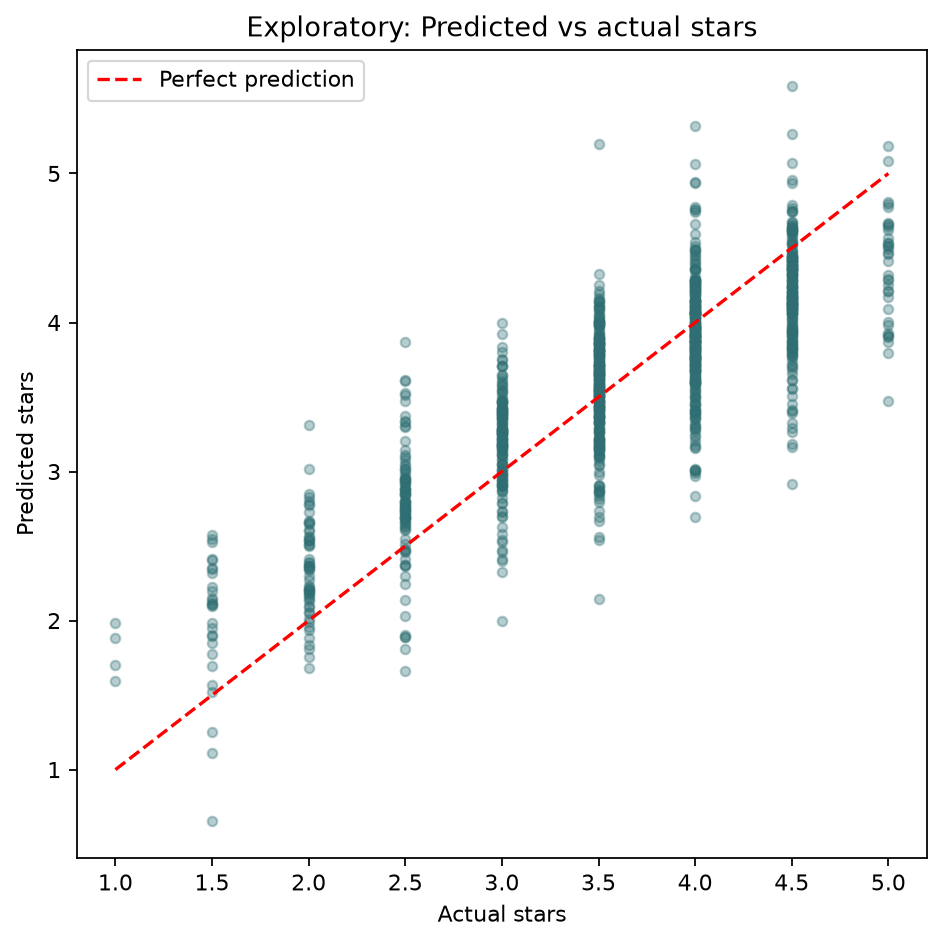

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.35, color="#2f6f73", s=18)
ax.plot([1, 5], [1, 5], "r--", label="Perfect prediction")
ax.set_title("Exploratory: Predicted vs actual stars")
ax.set_xlabel("Actual stars")
ax.set_ylabel("Predicted stars")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class5_exploratory_predicted_vs_actual.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Residual Plot

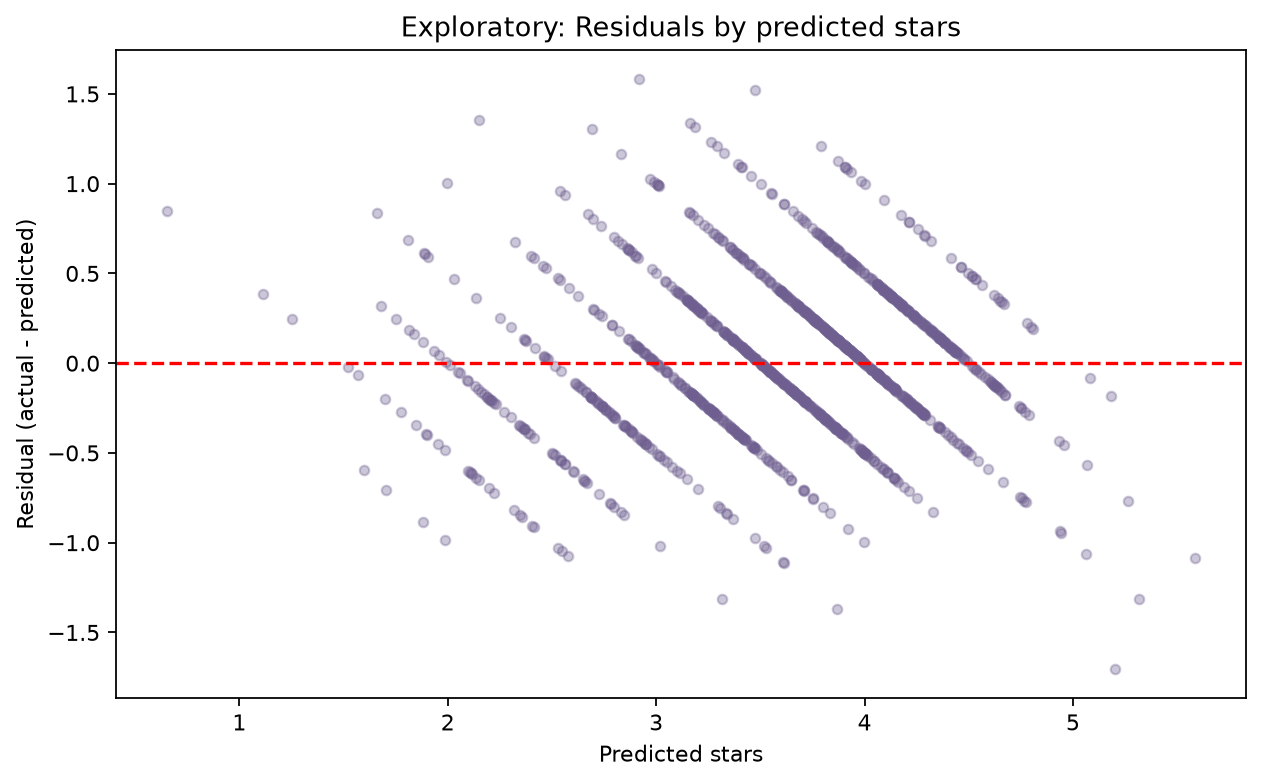

In [5]:
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.35, color="#6f5f90", s=18)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Exploratory: Residuals by predicted stars")
ax.set_xlabel("Predicted stars")
ax.set_ylabel("Residual (actual - predicted)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class5_exploratory_residuals.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Absolute Error Distribution

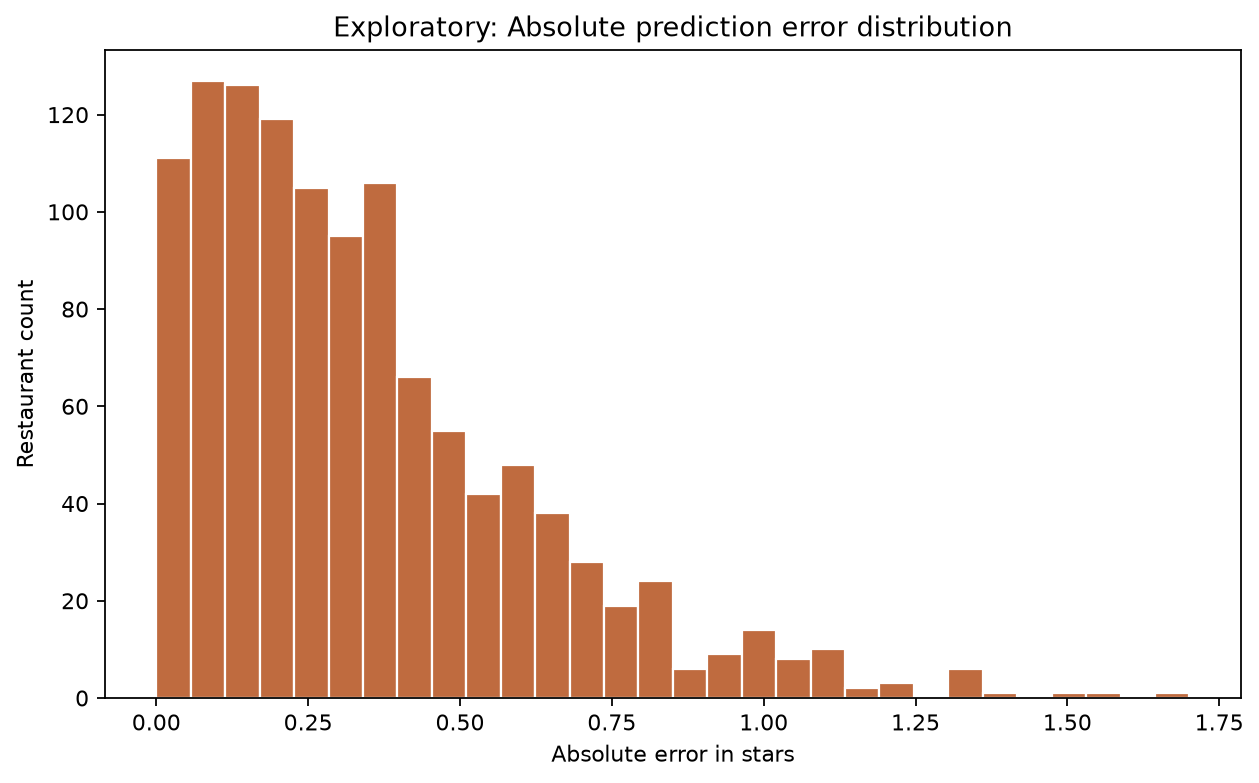

In [6]:
abs_errors = np.abs(residuals)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(abs_errors, bins=30, color="#bf6b3f", edgecolor="white")
ax.set_title("Exploratory: Absolute prediction error distribution")
ax.set_xlabel("Absolute error in stars")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class5_exploratory_absolute_error.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - How Close Are Predictions?

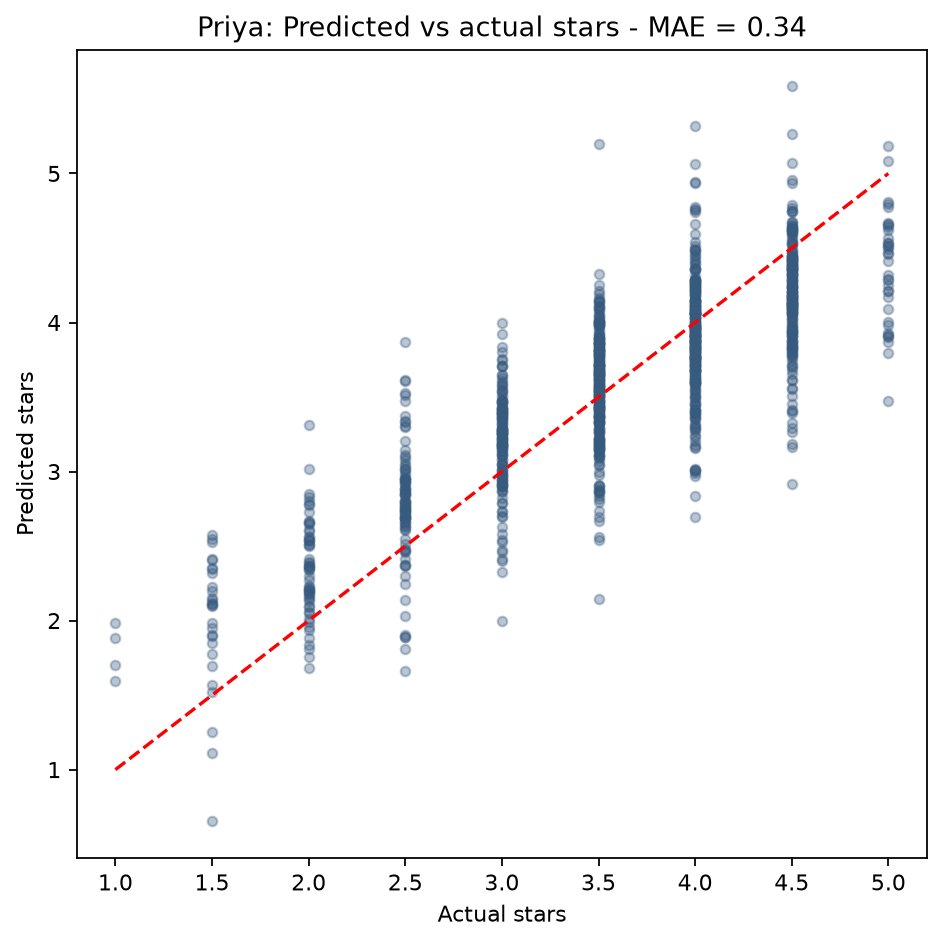

Takeaway: The baseline is off by about 0.34 stars on average. This is better than unknown, and Module 4 can improve it.


In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.35, color="#375a7f", s=18)
ax.plot([1, 5], [1, 5], "r--")
ax.set_title(f"Priya: Predicted vs actual stars - MAE = {mae:.2f}")
ax.set_xlabel("Actual stars")
ax.set_ylabel("Predicted stars")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class5_explanatory_prediction_quality.png", dpi=160)
plt.show()
print(f"Takeaway: The baseline is off by about {mae:.2f} stars on average. This is better than unknown, and Module 4 can improve it.")